ModuleNotFoundError: No module named 'google'

--- THÔNG TIN CHUNG CỦA TẬP DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB
None

--- 5 DÒNG ĐẦU DỮ LIỆU ---
   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8     

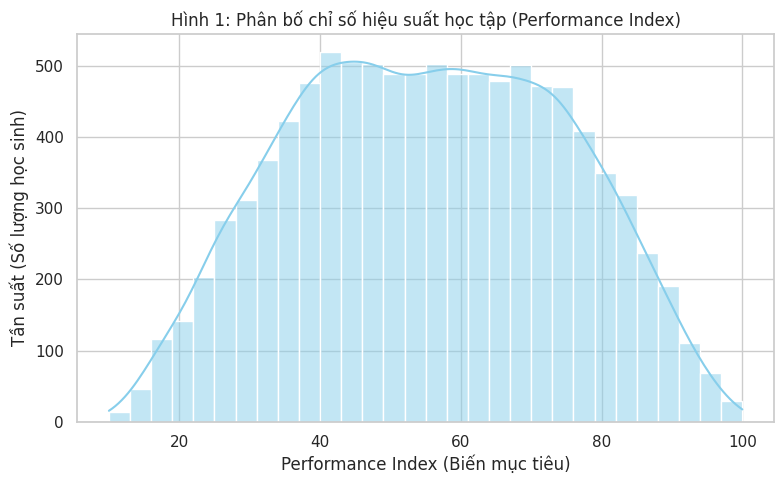

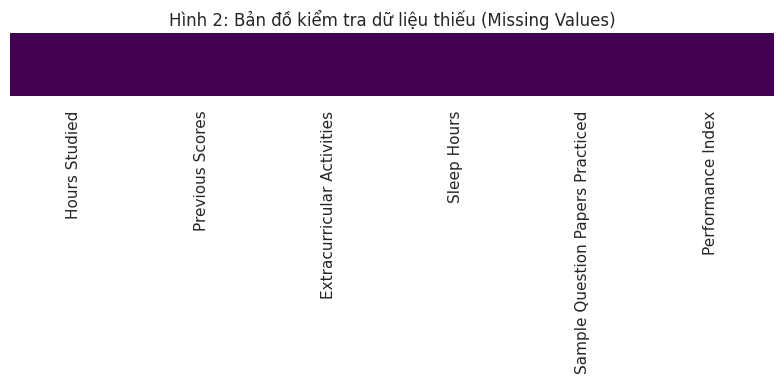

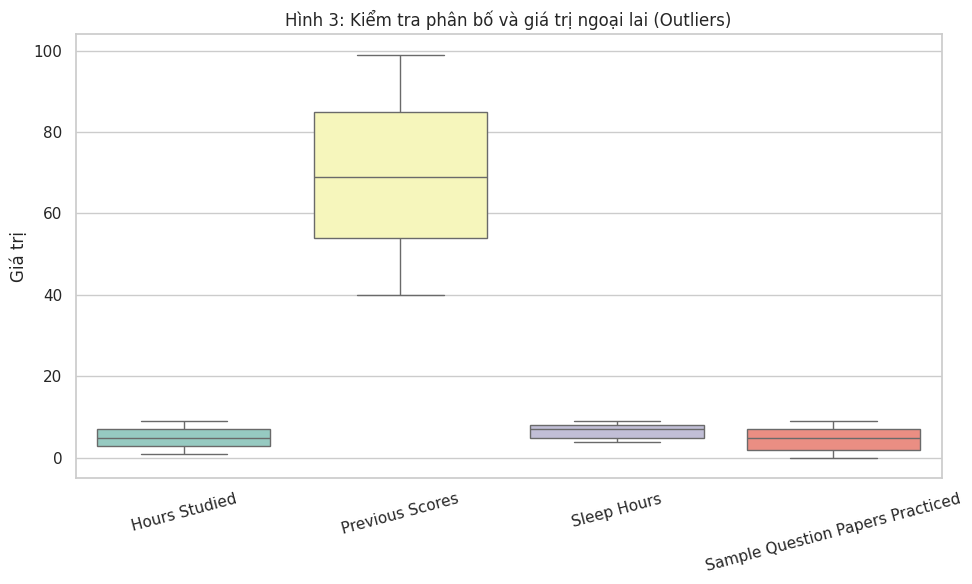

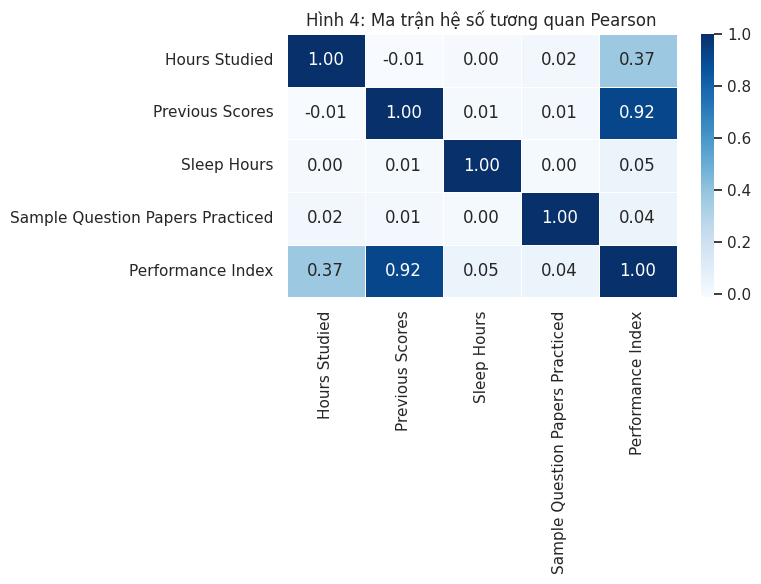

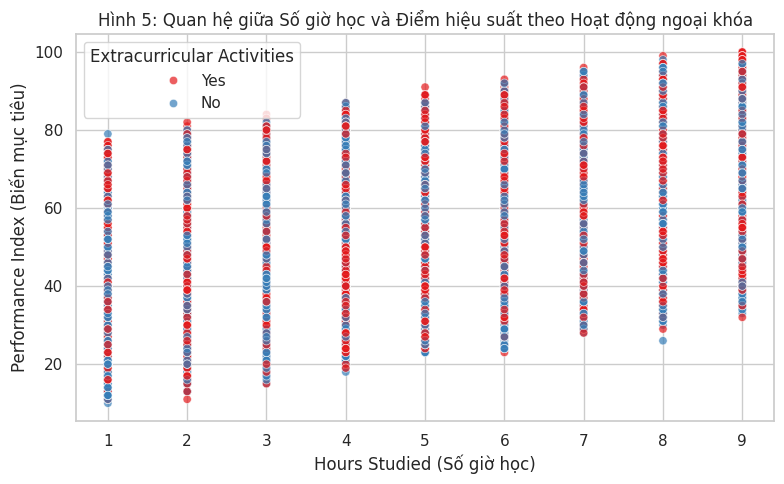


[THÀNH CÔNG] Đã xuất toàn bộ 5 hình vẽ vào thư mục: docs/figures


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cấu hình giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# Tạo thư mục docs/figures/ để lưu ảnh đúng yêu cầu
output_dir = "docs/figures"
os.makedirs(output_dir, exist_ok=True)

# 2. Đọc tập dữ liệu Student_Performance.csv
# LƯU Ý: Nếu file ở thư mục gốc Colab thì để "Student_Performance.csv"
# Nếu nạp từ Google Drive thì chỉnh lại đường dẫn cho đúng.
df = pd.read_csv("Student_Performance.csv")

print("--- THÔNG TIN CHUNG CỦA TẬP DỮ LIỆU ---")
print(df.info())
print("\n--- 5 DÒNG ĐẦU DỮ LIỆU ---")
print(df.head())

# Rename các cột về định dạng ngắn gọn để dễ làm việc (nếu cần)
# Giữ nguyên cấu trúc Kaggle gốc:
# ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']

# ==============================================================================
# HÌNH 1: Phân bố biến mục tiêu (Performance Index) - Histogram & KDE
# ==============================================================================
plt.figure(figsize=(8, 5))
sns.histplot(df['Performance Index'], kde=True, color='skyblue', bins=30)
plt.title('Hình 1: Phân bố chỉ số hiệu suất học tập (Performance Index)')
plt.xlabel('Performance Index (Biến mục tiêu)')
plt.ylabel('Tần suất (Số lượng học sinh)')
plt.tight_layout()
fig1_path = os.path.join(output_dir, "hinh1_target_distribution.png")
plt.savefig(fig1_path, dpi=300)
plt.show()

# ==============================================================================
# HÌNH 2: Bản đồ kiểm tra dữ liệu thiếu (Missing Values Heatmap)
# ==============================================================================
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Hình 2: Bản đồ kiểm tra dữ liệu thiếu (Missing Values)')
plt.tight_layout()
fig2_path = os.path.join(output_dir, "hinh2_missing_values.png")
plt.savefig(fig2_path, dpi=300)
plt.show()

# ==============================================================================
# HÌNH 3: Phân bố biến số & kiểm tra ngoại lai (Boxplot)
# ==============================================================================
plt.figure(figsize=(10, 6))
num_cols = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']
sns.boxplot(data=df[num_cols], palette='Set3')
plt.title('Hình 3: Kiểm tra phân bố và giá trị ngoại lai (Outliers)')
plt.ylabel('Giá trị')
plt.xticks(rotation=15)
plt.tight_layout()
fig3_path = os.path.join(output_dir, "hinh3_outliers_boxplot.png")
plt.savefig(fig3_path, dpi=300)
plt.show()

# ==============================================================================
# HÌNH 4: Ma trận tương quan giữa các biến định lượng (Correlation Heatmap)
# ==============================================================================
plt.figure(figsize=(8, 6))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Hình 4: Ma trận hệ số tương quan Pearson')
plt.tight_layout()
fig4_path = os.path.join(output_dir, "hinh4_correlation_heatmap.png")
plt.savefig(fig4_path, dpi=300)
plt.show()

# ==============================================================================
# HÌNH 5: Quan hệ giữa Số giờ học & Chỉ số hiệu suất theo Hoạt động ngoại khóa
# ==============================================================================
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Hours Studied',
    y='Performance Index',
    hue='Extracurricular Activities',
    alpha=0.7,
    palette='Set1'
)
plt.title('Hình 5: Quan hệ giữa Số giờ học và Điểm hiệu suất theo Hoạt động ngoại khóa')
plt.xlabel('Hours Studied (Số giờ học)')
plt.ylabel('Performance Index (Biến mục tiêu)')
plt.tight_layout()
fig5_path = os.path.join(output_dir, "hinh5_hours_vs_performance.png")
plt.savefig(fig5_path, dpi=300)
plt.show()

print(f"\n[THÀNH CÔNG] Đã xuất toàn bộ 5 hình vẽ vào thư mục: {output_dir}")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# Tạo thư mục lưu ảnh đúng yêu cầu của thầy
output_dir = "docs/figures"
os.makedirs(output_dir, exist_ok=True)

# Đọc dữ liệu từ file Student_Performance.csv
df = pd.read_csv("Student_Performance.csv")

# ==============================================================================
# HÌNH 1: Phân bố biến mục tiêu (Performance Index)
# ==============================================================================
plt.figure(figsize=(8, 5))
sns.histplot(df['Performance Index'], kde=True, color='#2b5c8f', bins=30)
plt.axvline(df['Performance Index'].mean(), color='red', linestyle='--', label=f"Trung bình: {df['Performance Index'].mean():.2f}")
plt.axvline(df['Performance Index'].median(), color='green', linestyle='-', label=f"Trung vị: {df['Performance Index'].median():.2f}")
plt.title('Hình 1: Phân bố biến mục tiêu Performance Index (N = 10,000)')
plt.xlabel('Performance Index')
plt.ylabel('Số lượng học sinh')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "hinh1_target_distribution.png"), dpi=300)
plt.show()

# ==============================================================================
# HÌNH 2: Bản đồ dữ liệu thiếu (Missing Values Heatmap)
# ==============================================================================
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Hình 2: Bản đồ kiểm tra dữ liệu khuyết thiếu (0% Missing)')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "hinh2_missing_values.png"), dpi=300)
plt.show()

# ==============================================================================
# HÌNH 3: Kiểm tra ngoại lai (Boxplot các biến số)
# ==============================================================================
plt.figure(figsize=(10, 5))
num_cols = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']
sns.boxplot(data=df[num_cols], palette='Set2')
plt.title('Hình 3: Biểu đồ hộp kiểm tra phân bố và ngoại lai')
plt.ylabel('Giá trị')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "hinh3_outliers_boxplot.png"), dpi=300)
plt.show()

# ==============================================================================
# HÌNH 4: Ma trận tương quan Pearson giữa các biến định lượng
# ==============================================================================
plt.figure(figsize=(8, 6))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='Blues', linewidths=0.5)
plt.title('Hình 4: Ma trận hệ số tương quan Pearson')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "hinh4_correlation_heatmap.png"), dpi=300)
plt.show()

# ==============================================================================
# HÌNH 5: Quan hệ giữa Previous Scores & Performance Index theo Hoạt động ngoại khóa
# ==============================================================================
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Previous Scores',
    y='Performance Index',
    hue='Extracurricular Activities',
    alpha=0.5,
    palette={'Yes': '#e74c3c', 'No': '#3498db'}
)
plt.title('Hình 5: Quan hệ tuyến tính giữa Điểm quá khứ và Chỉ số hiệu suất')
plt.xlabel('Previous Scores (40 - 99 điểm)')
plt.ylabel('Performance Index (10 - 100 điểm)')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "hinh5_scores_vs_performance.png"), dpi=300)
plt.show()

ModuleNotFoundError: No module named 'matplotlib'